# 02 — Bias Analysis

---

### Bias Dimensions Covered
1. **Gender disparate impact** — Four-Fifths Rule (DI ratio)
2. **Age-based discrimination** — approval patterns across age groups
3. **Proxy variables** — non-protected attributes acting as proxies for protected characteristics
4. **Interaction effects** — combined influence of gender × age on decisions

---

### Sections
1. Setup & Load Clean Data
2. Gender Disparate Impact (DI Ratio — Four-Fifths Rule)
3. Age-Based Discrimination Patterns
4. Proxy Variable Analysis
5. Interaction Effects Between Attributes
7. Consolidated Summary, Regulatory Mapping

## 1. Setup & Load Clean Data

- Loads the cleaned dataset produced by `01_data_quality.ipynb` 
- Derives `age` from `date_of_birth` and bins it into 6 age groups

### Bridge from Notebook 01 — Data Quality Issues Relevant to Bias

The data quality audit in Notebook 01 identified the following concrete issues. Each has a direct consequence for the fairness analysis performed in this notebook:

| Data Quality Issue (Notebook 01 finding) | Detail | Bias Implication |
|---|---|---|
| **Inconsistent gender coding** | 5 distinct values in `gender`: `'male'`, `'female'`, `'m'`, `'f'`, and unknown. Standardised to `'male'`/`'female'` by Notebook 01. | Records with non-standard values that could not be mapped were excluded from the DI calculation. If these records are not randomly distributed across approval outcomes, the gender DI ratio may be biased upward or downward. |
| **Four inconsistent date formats in `date_of_birth`** | Formats `YYYY/MM/DD`, `DD/MM/YYYY`, `YYYY-MM-DD`, and `MM/DD/YYYY` all present. Parsing errors produce `NaT`. | `NaT` values yield `NaN` ages, which are then excluded from all age-group analyses. If parsing failures cluster in a specific age cohort, the DI ratios for that group are unreliable. |
| **`annual_salary` merged into `annual_income`** | Two columns represented the same concept; non-null values from `annual_salary` were absorbed into `annual_income`, then `annual_salary` was dropped. | `annual_income` is a key financial predictor. Merging introduces imputed values from a secondary source — if the two columns had different measurement scales or populations, the merged column may carry noise that distorts the proxy analysis. |
| **Negative values in financial columns** | `credit_history_months < 0`, `savings_balance < 0`, `annual_income < 0`, `debt_to_income > 0.5` were all set to `NaN`. | These fields are the primary legitimate predictors of creditworthiness. Elevated NaN rates in any demographic group reduce statistical power for that group and can mask or exaggerate approval gaps. |
| **Duplicate SSNs with multiple names** | At least one SSN was linked to more than one `full_name` — a sign of either data entry error or identity inconsistency. Duplicates were resolved by forward/backward fill and deduplication on `_id`. | If a single applicant appears under multiple names with different approval outcomes, the duplicate resolution strategy determines which outcome is retained — introducing arbitrary bias for that individual. |
| **`spending_behavior` split into two columns** | The raw field was parsed into `spending_category` (categorical) and `spending_amount` (numeric). | `spending_category` is behavioural data. Spending patterns are known to correlate with both demographic group membership and financial outcomes, making this field a candidate proxy variable — examined in Section 4. |

> **Note:** The dataset used here (`clean_credit_applications.csv`) was produced by Notebook 01. The bias analysis reflects the *cleaned* data. Where Notebook 01 resolved ambiguity through imputation or deduplication, the chosen resolution strategy may itself introduce a form of systematic error that this notebook cannot fully detect.

In [1]:
# Install fairlearn if not already present
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fairlearn', '-q'])

CompletedProcess(args=['/Users/a.bauer/anaconda3/bin/python', '-m', 'pip', 'install', 'fairlearn', '-q'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency, norm
import warnings
warnings.filterwarnings('ignore')

try:
    from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
    FAIRLEARN_AVAILABLE = True
    print('✅ fairlearn loaded')
except ImportError:
    FAIRLEARN_AVAILABLE = False
    print('⚠️  fairlearn not available — DPD section will be skipped')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLOUR_MALE   = '#4C72B0'
COLOUR_FEMALE = '#DD8452'
THRESHOLD     = 0.8   # Four-Fifths Rule
np.random.seed(42)
print('Setup complete.')

✅ fairlearn loaded
Setup complete.


In [3]:
DATA_PATH = Path('../data/processed/clean_credit_applications.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('clean_dataset_view.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'Cleaned dataset not found. '
        'Run 01_data_quality.ipynb first and save to data/processed/clean_credit_applications.csv'
    )

df = pd.read_csv(DATA_PATH)

# Parse date columns safely
for col in ['date_of_birth', 'processing_timestamp']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Detect outcome column (handles both 'approved' and 'loan_approved')
if 'loan_approved' in df.columns:
    OUTCOME_COL = 'loan_approved'
elif 'approved' in df.columns:
    OUTCOME_COL = 'approved'
else:
    raise KeyError('No outcome column found. Expected "approved" or "loan_approved".')

df[OUTCOME_COL] = df[OUTCOME_COL].astype(int)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Outcome column: {OUTCOME_COL}')
print(f'Overall approval rate: {df[OUTCOME_COL].mean()*100:.1f}%')
df.head(3)

Dataset loaded: 499 rows x 21 columns
Outcome column: loan_approved
Overall approval rate: 58.1%


,_id,spending_behavior,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,...,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,loan_purpose,interest_rate,approved_amount,notes,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,male,2001-03-09,10036,...,23.0,0.20,31212.0,0,algorithm_risk_score,NaN,NaN,NaN,NaN,25.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaT,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,male,1992-03-31,10032,...,51.0,0.18,17915.0,0,algorithm_risk_score,NaN,NaN,NaN,NaN,33.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaT,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,male,1989-10-24,10075,...,41.0,0.21,37909.0,1,NaN,vacation,3.7,59000.0,NaN,36.0


In [4]:
# ── Derive age from date_of_birth ─────────────────────────────────────────────
if 'date_of_birth' in df.columns:
    reference_date = df['processing_timestamp'].dt.date if 'processing_timestamp' in df.columns else pd.Timestamp('today')
    df['age'] = (pd.Timestamp('today') - df['date_of_birth']).dt.days // 365
    df['age'] = df['age'].where(df['age'].between(18, 100))  # sanity bounds

AGE_BINS   = [18, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_group'] = pd.cut(df['age'], bins=AGE_BINS, labels=AGE_LABELS, right=False)

print('Age distribution:')
print(df['age_group'].value_counts().sort_index())
print(f'\nRecords with unknown age: {df["age"].isna().sum()}')

Age distribution:
age_group
18–24     11
25–34    149
35–44    180
45–54     87
55–64     56
65+       13
Name: count, dtype: int64

Records with unknown age: 3


## 2. Gender Disparate Impact

$$DI = \frac{\text{Approval rate of unprivileged group}}{\text{Approval rate of privileged group}}$$

**This section performs the following steps:**

1. Computes approval rates, approval counts, and rejection counts for male and female applicants
2. Determines the privileged and unprivileged group dynamically (whichever has the higher approval rate) and calculates the DI ratio (unprivileged / privileged approval rate)
3. Applies the Four-Fifths Rule: a DI below 0.8 is legally significant and triggers mandatory regulatory review; values between 0.8 and 0.9 are flagged as borderline
4. Produces three visualisations: a bar chart of approval rates by gender with the 4/5 threshold line, a DI ratio gauge showing where the result falls relative to the threshold zones, and a stacked bar chart of approved vs. rejected split by gender
5. Cross-validates the DI ratio using Fairlearn's `demographic_parity_difference` (absolute gap, ideal = 0) and `demographic_parity_ratio` (relative gap, ideal = 1)
6. Runs a chi-square test and a two-proportion z-test to assess whether the observed gender gap is statistically significant or could be due to sampling variation
7. Computes Cramér's V as an effect size measure to distinguish statistical significance from practical significance

In [5]:
df_gender = df[df['gender'].isin(['male', 'female'])].copy()

approval_stats = (
    df_gender
    .groupby('gender')[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
approval_stats['approval_rate_pct'] = (approval_stats['approval_rate'] * 100).round(2)
approval_stats['rejected_count']    = approval_stats['total'] - approval_stats['approved_count']

display(approval_stats.set_index('gender'))

,total,approved_count,approval_rate,approval_rate_pct,rejected_count
gender,,,,,
female,251,127,0.505976,50.60,124
male,248,163,0.657258,65.73,85


Groups are more or less balanced (251 vs 248). Raw approval gap: 15.1 percentage points in favour of male applicants (absolute difference), resulting in a 23% relative difference.

In [6]:
rate = approval_stats.set_index('gender')['approval_rate']

approval_rate_male   = rate['male']
approval_rate_female = rate['female']

if approval_rate_male >= approval_rate_female:
    privileged_rate, unprivileged_rate = approval_rate_male, approval_rate_female
    privileged_label, unprivileged_label = 'male', 'female'
else:
    privileged_rate, unprivileged_rate = approval_rate_female, approval_rate_male
    privileged_label, unprivileged_label = 'female', 'male'

DI_ratio = unprivileged_rate / privileged_rate

if DI_ratio < THRESHOLD:
    verdict  = '⚠️  DISPARATE IMPACT DETECTED'
    severity = 'Potential discrimination — regulatory review required.'
elif DI_ratio < 0.9:
    verdict  = '🔶  BORDERLINE'
    severity = 'Below ideal parity. Monitoring recommended.'
else:
    verdict  = '✅  PASSES FOUR-FIFTHS RULE'
    severity = 'Approval rates are roughly comparable across groups.'

print('=' * 55)
print('  DISPARATE IMPACT ANALYSIS — FOUR-FIFTHS RULE')
print('=' * 55)
print(f'  Privileged group   ({privileged_label:>6}):  {privileged_rate:.4f}  ({privileged_rate*100:.2f}%)')
print(f'  Unprivileged group ({unprivileged_label:>6}):  {unprivileged_rate:.4f}  ({unprivileged_rate*100:.2f}%)')
print('-' * 55)
print(f'  DI Ratio = {unprivileged_rate:.4f} / {privileged_rate:.4f} = {DI_ratio:.4f}')
print(f'  Threshold                            = {THRESHOLD}')
print('-' * 55)
print(f'  {verdict}')
print(f'  {severity}')
print('=' * 55)

  DISPARATE IMPACT ANALYSIS — FOUR-FIFTHS RULE
  Privileged group   (  male):  0.6573  (65.73%)
  Unprivileged group (female):  0.5060  (50.60%)
-------------------------------------------------------
  DI Ratio = 0.5060 / 0.6573 = 0.7698
  Threshold                            = 0.8
-------------------------------------------------------
  ⚠️  DISPARATE IMPACT DETECTED
  Potential discrimination — regulatory review required.


With an DI of 0.7698 we are below the legal threshold of 0.80.

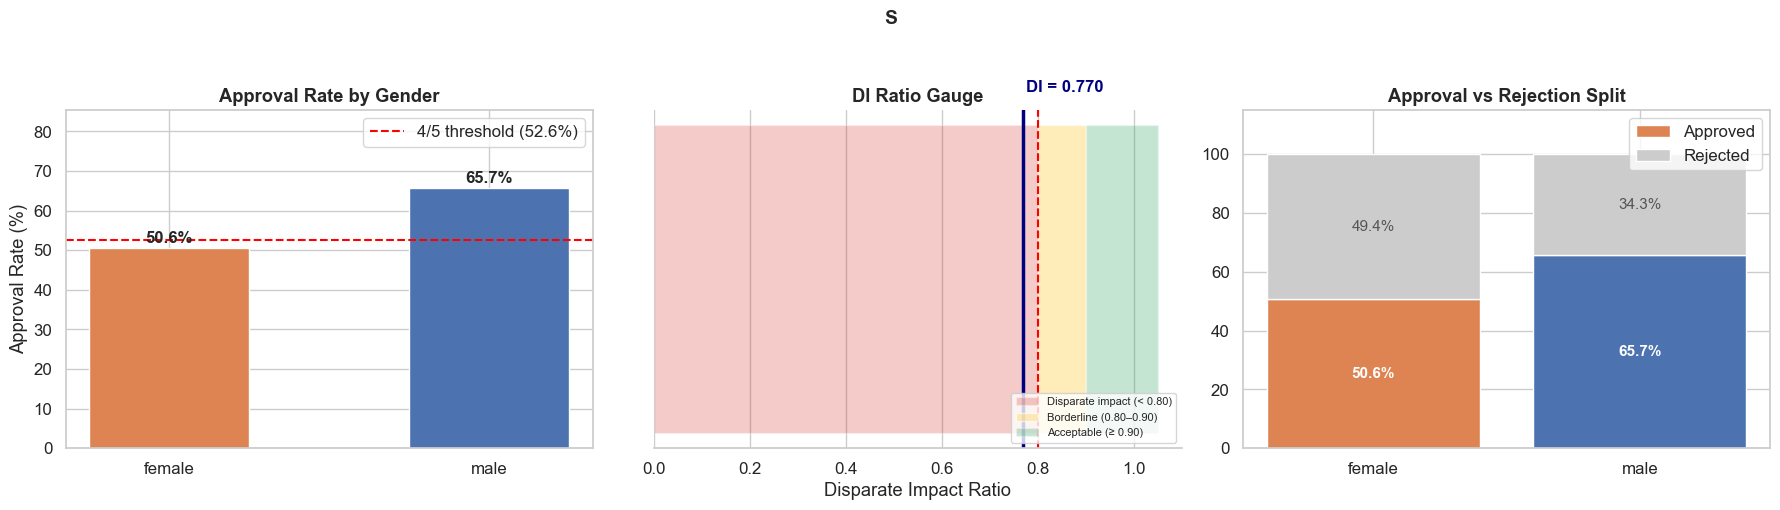

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colours = {'male': COLOUR_MALE, 'female': COLOUR_FEMALE}

# ---- Left: approval rate bars ----
ax1 = axes[0]
bars = ax1.bar(
    approval_stats['gender'],
    approval_stats['approval_rate_pct'],
    color=[colours[g] for g in approval_stats['gender']],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, approval_stats['approval_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
threshold_pct = privileged_rate * THRESHOLD * 100
ax1.axhline(threshold_pct, color='red', linestyle='--', linewidth=1.5,
            label=f'4/5 threshold ({threshold_pct:.1f}%)')
ax1.set_title('Approval Rate by Gender', fontweight='bold')
ax1.set_ylabel('Approval Rate (%)')
ax1.set_ylim(0, max(approval_stats['approval_rate_pct']) * 1.3)
ax1.legend()

# ---- Middle: DI gauge ----
ax2 = axes[1]
ax2.barh(['DI Ratio'], [0.80], color='#d73027', alpha=0.25, height=0.5, label='Disparate impact (< 0.80)')
ax2.barh(['DI Ratio'], [0.10], left=0.80, color='#fee08b', alpha=0.6,  height=0.5, label='Borderline (0.80–0.90)')
ax2.barh(['DI Ratio'], [0.15], left=0.90, color='#1a9850', alpha=0.25, height=0.5, label='Acceptable (≥ 0.90)')
ax2.axvline(DI_ratio, color='navy', linewidth=2.5)
ax2.text(DI_ratio + 0.005, 0.3, f'DI = {DI_ratio:.3f}',
         va='bottom', ha='left', fontsize=12, fontweight='bold', color='navy')
ax2.axvline(THRESHOLD, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlim(0, 1.1)
ax2.set_xlabel('Disparate Impact Ratio')
ax2.set_title('DI Ratio Gauge', fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.set_yticks([])
sns.despine(ax=ax2, left=True)

# ---- Right: stacked pct ----
ax3 = axes[2]
genders       = approval_stats['gender'].tolist()
approved_pcts = approval_stats['approval_rate_pct'].tolist()
rejected_pcts = (100 - approval_stats['approval_rate_pct']).tolist()
ax3.bar(genders, approved_pcts, color=[colours[g] for g in genders], label='Approved', edgecolor='white')
ax3.bar(genders, rejected_pcts, bottom=approved_pcts, color='#cccccc', label='Rejected', edgecolor='white')
for i, (a, r) in enumerate(zip(approved_pcts, rejected_pcts)):
    ax3.text(i, a/2,   f'{a:.1f}%', ha='center', va='center', fontweight='bold', color='white',   fontsize=11)
    ax3.text(i, a+r/2, f'{r:.1f}%', ha='center', va='center', color='#555', fontsize=11)
ax3.set_title('Approval vs Rejection Split', fontweight='bold')
ax3.set_ylim(0, 115)
ax3.legend()

plt.suptitle('S', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
Path('../reports').mkdir(parents=True, exist_ok=True)
plt.savefig('../reports/bias_gender_di.png', dpi=150, bbox_inches='tight')
plt.show()

The 4/5 threshold line in the left bar chart sits at 52.6%. The female bar at 50.6% falls below this line, which visually confirms the DI violation.

The DI gauge shows the result at 0.770, being very close the 0.8 threshold, but still underneath of it.

The stacked bar chart shows visually that female applicants have a 49.4% rejection rate vs. 34.3% for males — so nearly half of all female applicants are rejected.

In [8]:
if FAIRLEARN_AVAILABLE:
    y_true      = df_gender[OUTCOME_COL].values
    sensitive_f = df_gender['gender'].values
    dpd = demographic_parity_difference(y_true=y_true, y_pred=y_true, sensitive_features=sensitive_f)
    dpr = demographic_parity_ratio(     y_true=y_true, y_pred=y_true, sensitive_features=sensitive_f)
    print(f'Demographic Parity Difference : {dpd:+.4f}  (ideal = 0)')
    print(f'Demographic Parity Ratio      :  {dpr:.4f}  (ideal = 1)')
else:
    print('fairlearn not available')

Demographic Parity Difference : +0.1513  (ideal = 0)
Demographic Parity Ratio      :  0.7698  (ideal = 1)


Demographic Parity Difference (DPD) = +0.1513 —> this is the absolute approval rate gap (same as the 15.1 pp). The sign (+) means male is the higher group.

Demographic Parity Ratio (DPR) = 0.7698 —> this is exactly the DI ratio, just computed via Fairlearn as a cross-check. It confirms the manual calculation is correct.

DPD and DPR can sometimes tell different stories when group sizes are very unequal — here the groups are nearly equal (251 vs 248), so both metrics point to the same conclusion, which strengthens confidence in the finding.

In [9]:
# ── Statistical tests — Gender vs Approval ───────────────────────────────────

# ---- 1. Chi-square test -------------------------------------------------------
contingency_gender = pd.crosstab(df_gender['gender'], df_gender[OUTCOME_COL])
chi2_g, p_chi2_g, dof_g, _ = chi2_contingency(contingency_gender)

# ---- 2. Two-proportion z-test (more precise for exactly 2 groups) ------------
n_male   = approval_stats.set_index('gender').loc['male',   'total']
n_female = approval_stats.set_index('gender').loc['female', 'total']
x_male   = approval_stats.set_index('gender').loc['male',   'approved_count']
x_female = approval_stats.set_index('gender').loc['female', 'approved_count']

p_pool  = (x_male + x_female) / (n_male + n_female)
se      = np.sqrt(p_pool * (1 - p_pool) * (1/n_male + 1/n_female))
z_stat  = (approval_rate_male - approval_rate_female) / se
p_ztest = 2 * (1 - norm.cdf(abs(z_stat)))   # two-tailed

# ---- 3. Effect size: Cramér's V ----------------------------------------------
n_total   = len(df_gender)
cramers_v = np.sqrt(chi2_g / (n_total * (min(contingency_gender.shape) - 1)))

print('=' * 55)
print('  STATISTICAL TESTS — GENDER vs APPROVAL')
print('=' * 55)
print(f'  1. Chi-square test:')
print(f'     χ² = {chi2_g:.4f},  p = {p_chi2_g:.6f},  df = {dof_g}')
print()
print(f'  2. Two-proportion z-test:')
print(f'     z  = {z_stat:.4f},  p = {p_ztest:.6f}')
print()
print(f'  3. Effect size (Cramér\'s V): {cramers_v:.4f}')
print(f'     (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)')
print('-' * 55)
if p_ztest < 0.05:
    print('  ⚠️  Statistically significant gender gap in approval (p < 0.05)')
    print('     The DI ratio reflects a real pattern, not random variation.')
else:
    print('  ✅ Gender gap is not statistically significant (p ≥ 0.05)')
    print('     The DI ratio may reflect sampling noise.')
print('=' * 55)

  STATISTICAL TESTS — GENDER vs APPROVAL
  1. Chi-square test:
     χ² = 11.1156,  p = 0.000856,  df = 1

  2. Two-proportion z-test:
     z  = 3.4247,  p = 0.000615

  3. Effect size (Cramér's V): 0.1493
     (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)
-------------------------------------------------------
  ⚠️  Statistically significant gender gap in approval (p < 0.05)
     The DI ratio reflects a real pattern, not random variation.


The Chi-square and z-test agree: the 15.1 % approval rate gap between female and male is not sampling noise. It reflects a real pattern in the data.

The Cramér's V test classifies it as a small effect. The gap is statistically real but moderate in magnitude. Gender alone does not dominate the approval decision, other features should also play a role.

### Key takeaways — Gender Disparate Impact

- Female applicants are approved at a rate approximately 23% (relative difference) lower than male applicants on a relative basis (DI = 0.77)
- The disparate impact ratio falls below the 0.8 threshold and the difference is statistically significant (p < 0.001), suggesting a disparity that needs attention.
- The small effect size (Cramér's V) suggests the disparity is likely driven at least partly through proxy variables (e.g. income, credit history) rather than gender being directly decisive — this will be examined in Section 4
- A single-gender DI check is insufficient: Section 5 will test whether the gap is uniform across all age groups or concentrated in specific intersectional subgroups



## 3. Age-Based Discrimination Patterns
 
We examine whether approval rates differ materially across age groups and compute the DI ratio for each group relative to the highest-approval group.

**This section performs the following steps:**

1. Computes approval rates, approval counts, rejection counts, and DI ratios for each of the six age groups (18–24, 25–34, 35–44, 45–54, 55–64, 65+), flagging any group below the 0.8 threshold as disparate impact and between 0.8–0.9 as borderline
2. Produces two visualisations: a colour-coded bar chart of approval rates by age group (red = DI < 0.8, yellow = borderline, green = OK) with the 4/5 threshold line, and a line chart of DI ratios across age groups with colour-coded threshold zones
3. Runs a chi-square test to assess whether the association between age group and approval outcome is statistically significant or could be due to chance
4. Computes Cramér's V as an effect size measure to contextualise the magnitude of any statistically significant association

In [10]:
df_age = df.dropna(subset=['age_group', OUTCOME_COL]).copy()

age_stats = (
    df_age
    .groupby('age_group', observed=True)[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
age_stats['approval_rate_pct'] = (age_stats['approval_rate'] * 100).round(2)
age_stats['rejected_count']    = age_stats['total'] - age_stats['approved_count']

# DI ratio: each group vs the group with the highest approval rate
max_rate = age_stats['approval_rate'].max()
age_stats['DI_ratio'] = (age_stats['approval_rate'] / max_rate).round(4)
age_stats['DI_flag']  = age_stats['DI_ratio'].apply(
    lambda x: '⚠️  Disparate impact' if x < 0.8 else ('🔶 Borderline' if x < 0.9 else '✅ OK')
)

print('=== Age Group Approval Rates ===')
display(age_stats.set_index('age_group'))

=== Age Group Approval Rates ===


,total,approved_count,approval_rate,approval_rate_pct,rejected_count,DI_ratio,DI_flag
age_group,,,,,,,
18–24,11,6,0.545455,54.55,5,0.8320,🔶 Borderline
25–34,149,66,0.442953,44.30,83,0.6757,⚠️ Disparate impact
35–44,180,118,0.655556,65.56,62,1.0000,✅ OK
45–54,87,56,0.643678,64.37,31,0.9819,✅ OK
55–64,56,35,0.625000,62.50,21,0.9534,✅ OK
65+,13,7,0.538462,53.85,6,0.8214,🔶 Borderline


Only one group triggers full disparate impact: 25–34 with DI = 0.6757. This is well below the 0.8 threshold, with a 44.3% approval rate and the largest absolute sample (n=149).

Two groups sit in the borderline zone: 18–24 (DI = 0.832, but n=11 — extremely small, interpret with caution) and 65+ (DI = 0.821, n=13 — same caveat). However the small sample sizes for these two groups (n=11 and n=13) mean their DI ratios are statistically unreliable, a single approval decision could shift their flags.

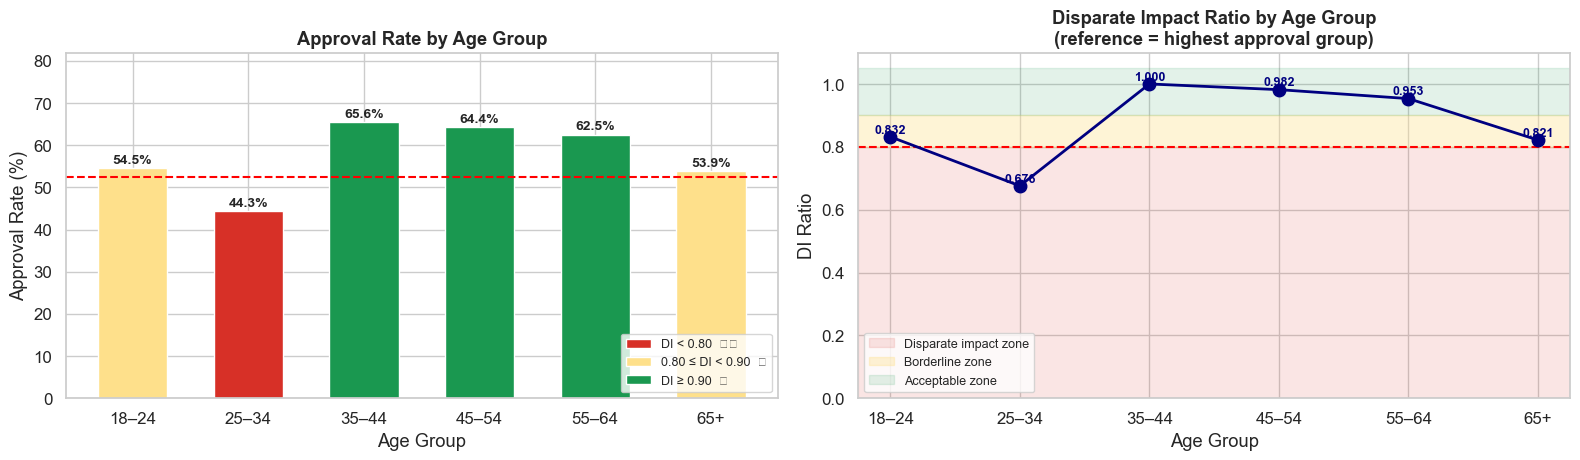

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left: approval rate by age group ----
ax1 = axes[0]
bar_colours = ['#d73027' if di < 0.8 else ('#fee08b' if di < 0.9 else '#1a9850')
               for di in age_stats['DI_ratio']]
bars = ax1.bar(age_stats['age_group'].astype(str), age_stats['approval_rate_pct'],
               color=bar_colours, edgecolor='white', width=0.6)
for bar, val in zip(bars, age_stats['approval_rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.axhline(max_rate * THRESHOLD * 100, color='red', linestyle='--', linewidth=1.5,
            label=f'4/5 threshold ({max_rate * THRESHOLD * 100:.1f}%)')
ax1.set_title('Approval Rate by Age Group', fontweight='bold')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Approval Rate (%)')
ax1.set_ylim(0, max(age_stats['approval_rate_pct']) * 1.25)
ax1.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='DI < 0.80  ⚠️'),
                   Patch(facecolor='#fee08b', label='0.80 ≤ DI < 0.90  🔶'),
                   Patch(facecolor='#1a9850', label='DI ≥ 0.90  ✅')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# ---- Right: DI ratio by age group ----
ax2 = axes[1]
ax2.axhspan(0,    0.80, color='#d73027', alpha=0.12, label='Disparate impact zone')
ax2.axhspan(0.80, 0.90, color='#fee08b', alpha=0.35, label='Borderline zone')
ax2.axhspan(0.90, 1.05, color='#1a9850', alpha=0.12, label='Acceptable zone')
ax2.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax2.plot(age_stats['age_group'].astype(str), age_stats['DI_ratio'],
         marker='o', markersize=9, color='navy', linewidth=2, zorder=5)
for i, row in age_stats.iterrows():
    ax2.text(i, row['DI_ratio'] + 0.012, f"{row['DI_ratio']:.3f}",
             ha='center', fontsize=9, fontweight='bold', color='navy')
ax2.set_title('Disparate Impact Ratio by Age Group\n(reference = highest approval group)', fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('DI Ratio')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)

plt.suptitle('', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/bias_age_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart makes the 25–34 gap visually stark: it is the only group clearly below the red dashed threshold line at 52.5%, and the only red bar.

The DI line chart shows a sharp V-shape: DI drops from 0.832 (18–24) to 0.676 (25–34), then jumps to 1.000 (35–44), and gradually declines again toward 65+. The DI values of the two groups furthest out (18-24, 65+) should be treated with caution due to their small sample size.
Still this pattern suggests that the disadvantage for the 25–34 group reflects a distinct disparity rather than a gradual change with age.

In [12]:
# ── Statistical tests — Age Group vs Approval ───────────────────────────────

# ---- 1. Chi-square test ------------------------------------------------------
contingency_age = pd.crosstab(df_age['age_group'], df_age[OUTCOME_COL])
chi2_age, p_value, dof_age, _ = chi2_contingency(contingency_age)

# ---- 2. Effect size: Cramér's V ----------------------------------------------
n_age     = len(df_age)
cramers_v_age = np.sqrt(chi2_age / (n_age * (min(contingency_age.shape) - 1)))

print('=' * 55)
print('  STATISTICAL TESTS — AGE GROUP vs APPROVAL')
print('=' * 55)
print(f'  Chi-square test:')
print(f'    χ² = {chi2_age:.4f},  p = {p_value:.6f},  df = {dof_age}')
print()
print(f'  Effect size (Cramér\'s V): {cramers_v_age:.4f}')
print(f'    (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)')
print('-' * 55)
if p_value < 0.05:
    print('  ⚠️  Statistically significant association between age group and approval (p < 0.05).')
    print('     This does not prove causation but warrants further investigation.')
else:
    print('  ✅ No statistically significant association detected (p ≥ 0.05).')
print('=' * 55)

  STATISTICAL TESTS — AGE GROUP vs APPROVAL
  Chi-square test:
    χ² = 17.7727,  p = 0.003245,  df = 5

  Effect size (Cramér's V): 0.1893
    (< 0.1 = negligible,  0.1–0.3 = small,  > 0.3 = medium)
-------------------------------------------------------
  ⚠️  Statistically significant association between age group and approval (p < 0.05).
     This does not prove causation but warrants further investigation.


The chi-square looking into the association between age group and approval outcome is statistically significant (p = 0.003245), indicating that the approval gap across age groups, in particular the 25–34 dip, is not sampling noise. It reflects a real pattern in the data.

The result of Cramér's V (0.1893) is a small effect, meaning age group membership does not dominate the decision but contributes meaningfully.

### Key takeaways — Age-Based Discrimination Patterns

- Applicants aged 25–34 are approved at a rate approximately 33% lower than the reference group (35–44) on a relative basis (DI = 0.676) 
- The borderline groups (18–24: DI = 0.832, 65+: DI = 0.821) should be interpreted cautiously given their very small sample sizes (n=11 and n=13 respectively)
- The association between age group and approval is statistically significant (χ² = 17.77, p = 0.003) and the chi-square and DI analysis agree: the approval gap across age groups reflects a real pattern in the data.
- The age effect (Cramér's V = 0.189) is slightly stronger than the gender effect found in Section 2 (V = 0.149), making age group at least as relevant a fairness dimension in this dataset

A single-axis age check is insufficient: Section 5 will test whether the 25–34 disadvantage is uniform across genders or concentrated in a specific intersectional subgroup such as women aged 25–34

## 4. Proxy Variable Analysis

A proxy variable is a non-protected feature that is highly correlated with a protected attribute (gender, age) AND with the outcome. If the model uses such a feature, it can produce discriminatory outcomes even without directly using the protected attribute.

**This section performs the following steps:**

1. For each numeric feature, computes three correlations and their p-values: point-biserial correlation with `gender` (binary-encoded), Pearson correlation with `age`, and point-biserial correlation with the approval outcome; `spending_category` (categorical), computes Cramér's V against gender, age_group, and the outcome separately
2. Calculates a composite proxy risk score = max(|corr_gender|, |corr_age|) × |corr_outcome|, and classifies each feature as high (> 0.15), medium (> 0.07), or low proxy risk; displays a ranked summary table
3. Produces a correlation heatmap showing all features ranked by their maximum protected-attribute correlation, with columns for corr_gender, corr_age, corr_outcome, and proxy_risk_score

In [13]:
df_proxy = df.copy()
df_proxy['gender_binary'] = (df_proxy['gender'] == 'male').astype(float)

EXCLUDE = {OUTCOME_COL, 'gender', 'gender_binary', 'age', '_id',
           'processing_timestamp', 'date_of_birth', 'age_group'}
numeric_cols = [c for c in df_proxy.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]
print(f'Features tested: {numeric_cols}')

results = []
for col in numeric_cols:
    valid = df_proxy[[col, 'gender_binary', 'age', OUTCOME_COL]].dropna()
    if len(valid) < 30:
        continue
    r_gender,  p_gender  = pointbiserialr(valid['gender_binary'], valid[col])
    r_age,     p_age     = stats.pearsonr(valid['age'], valid[col])
    r_outcome, p_outcome = pointbiserialr(valid[OUTCOME_COL], valid[col])
    results.append({
        'feature':      col,
        'corr_gender':  round(r_gender,  3),
        'p_gender':     round(p_gender,  4),
        'corr_age':     round(r_age,     3),
        'p_age':        round(p_age,     4),
        'corr_outcome': round(r_outcome, 3),
        'p_outcome':    round(p_outcome, 4),
    })

if 'spending_category' in df_proxy.columns:
    df_spend = df_proxy[['spending_category', 'gender_binary', 'age_group', OUTCOME_COL]].dropna()
    def cramers_v(ct):
        chi2, _, _, _ = chi2_contingency(ct)
        n = ct.values.sum()
        return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    v_gender  = cramers_v(pd.crosstab(df_spend['spending_category'], df_spend['gender_binary']))
    v_age     = cramers_v(pd.crosstab(df_spend['spending_category'], df_spend['age_group']))
    v_outcome = cramers_v(pd.crosstab(df_spend['spending_category'], df_spend[OUTCOME_COL]))
    results.append({
        'feature':      'spending_category',
        'corr_gender':  round(v_gender,  3),  # Cramér's V, not point-biserial r
        'p_gender':     np.nan,
        'corr_age':     round(v_age,     3),  # Cramér's V, not Pearson r
        'p_age':        np.nan,
        'corr_outcome': round(v_outcome, 3),
        'p_outcome':    np.nan,
    })

proxy_df = pd.DataFrame(results).sort_values('corr_gender', key=abs, ascending=False)

print('\n=== Proxy Variable Analysis ===')
display(proxy_df.set_index('feature'))

Features tested: ['zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'interest_rate', 'approved_amount']

=== Proxy Variable Analysis ===


,corr_gender,p_gender,corr_age,p_age,corr_outcome,p_outcome
feature,,,,,,
zip_code,-0.805,0.0000,0.046,0.3113,-0.120,0.0073
approved_amount,0.067,0.2596,0.085,0.1502,NaN,NaN
interest_rate,0.056,0.3455,0.085,0.1498,NaN,NaN
debt_to_income,0.054,0.2267,-0.069,0.1250,-0.001,0.9787
annual_income,-0.042,0.3501,0.394,0.0000,0.180,0.0001
credit_history_months,-0.021,0.6372,0.649,0.0000,0.147,0.0010
savings_balance,-0.002,0.9731,0.286,0.0000,0.134,0.0027


`Interest_rate` and `approved_amount` are post-decision fields — they only have values when a loan was approved, so they're NaN for every rejected application.

`Spending_category` uses Cramér's V (not point-biserial r), hence NaN p-values.

The values in corr_gender, corr_age, and corr_outcome represent association strength, not correlation direction.

Features are considered potential proxy variables if the absolute correlation with a protected attribute exceeds 0.3 (Cohen, 1988: moderate effect) and simultaneously shows a meaningful association with the outcome (|r| > 0.1). Below this threshold, the correlation is too weak to systematically transmit demographic bias through the model.

There are no high-risk proxies detected as no feature crosses the 0.15 threshold.
Three medium-risk proxies: `zip_code` (0.099), `credit_history_months` (0.095), `annual_income` (0.071)

`spending_category` lands at 0.043 which is low risk, but its corr_outcome (0.198) is the highest outcome association of any feature in the table, meaning spending category is the single strongest predictor of approval.
Its low proxy score is explained by its moderate protected-attribute associations (0.218 with gender, 0.160 with age): not strong enough to push it into medium risk, but important to watch it further.

`spending_amount` has near-zero correlations with gender, age and outcome. It carries no proxy risk and no predictive weight.

`debt_to_income` has near-zero correlations as well, the NaN truncation in the data quality part has likely suppressed any real signal.

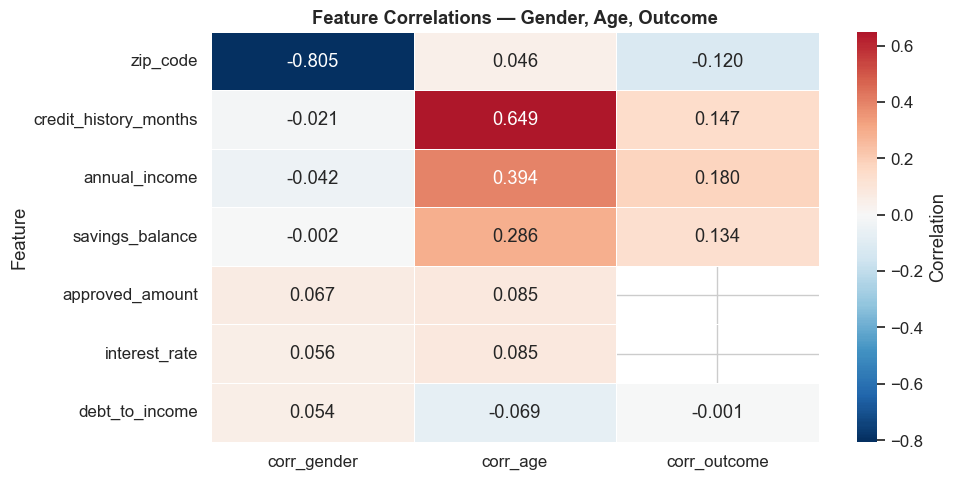

In [14]:
# ── Correlation heatmap: all numeric features vs outcome ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Ensure column exists
proxy_df['max_protected_corr'] = proxy_df[['corr_gender','corr_age']].abs().max(axis=1)

# Sort BEFORE selecting columns — max_protected_corr is dropped after
corr_outcome = (
    proxy_df
    .sort_values('max_protected_corr', ascending=False)   # sort on full df
    .set_index('feature')
    [['corr_gender','corr_age','corr_outcome']]  # then select
)

sns.heatmap(corr_outcome, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlations — Gender, Age, Outcome', fontweight='bold')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/bias_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap makes the asymmetry between gender and age proxies immediately visible: `zip_code` dominates the corr_gender column (−0.805, deep blue) while `credit_history_months` dominates the corr_age column (0.649, deep red). These are structurally different risks.

`annual_income` shows a moderate but consistent pattern across age (0.394) and outcome (0.180): not dominant in any single column but broadly correlated across the board

`savings_balance` is a mild age correlate (0.286) with a small outcome effect (0.134) — borderline medium-risk that just missed the threshold

`spending_category` is mid-table with a corr_outcome cell (0.198) — the strongest outcome predictor in the dataset, yet classified low-risk because its demographic associations are moderate rather than strong.


### Key takeaways — Proxy Variable Analysis

- No features cross the high-risk threshold — but three medium-risk proxies (`zip_code`, `credit_history_month`, `annual_income`) require attention
- `zip_code` is the strongest gender proxy in the dataset (corr = −0.805), meaning location encodes gender information almost as strongly as gender itself. If a model uses zip_code, it can replicate the gender gap found in Section 2 without ever seeing the gender column
- `credit_history_months` is the primary age proxy (corr = 0.649 with age, p < 0.0001) and also meaningfully predicts approval (0.147). This is the most likely mechanism behind the 25–34 disadvantage identified in Section 3, as younger applicants mechanically have shorter credit histories
- `spending_category` is the strongest predictor of the approval outcome in the entire dataset (Cramér's V = 0.198). This warrants attention: a feature that strongly predicts the outcome while carrying moderate demographic associations can still drive disparate impact in practice, even without crossing the proxy risk threshold

## 5. Interaction Effects Between Attributes

Interaction effects occur when the combination of two protected attributes produces  
a discriminatory pattern that neither attribute alone would reveal.

**This section performs the following steps:**

1. Computes approval rates and DI ratios for every gender × age group combination (up to 12 subgroups), using the global maximum approval rate as the reference, and displays a summary table
2. Produces two heatmaps: one showing approval rate (%) per gender × age group cell, and one showing the DI ratio per cell with colour coding relative to the 0.8 threshold
3. Produces a grouped bar chart of approval rates by age group, split by gender, with the 4/5 threshold line for visual comparison
4. Identifies and lists any gender × age subgroups with DI < 0.8, flagging intersectional disparate impact that single-axis analyses (gender alone or age alone) would miss
5. Runs a chi-square test and computes Cramér's V within each age group to test whether gender discrimination is statistically significant at the subgroup level, confirming or ruling out intersectional bias

In [15]:
df_interact = df_gender.dropna(subset=['age_group']).copy()

# ── Approval rate: gender × age group ─────────────────────────────────────────
interaction_stats = (
    df_interact
    .groupby(['age_group', 'gender'], observed=True)[OUTCOME_COL]
    .agg(total='count', approved_count='sum', approval_rate='mean')
    .reset_index()
)
interaction_stats['approval_rate_pct'] = (interaction_stats['approval_rate'] * 100).round(2)

# DI ratio for each subgroup vs overall max
global_max_rate = interaction_stats['approval_rate'].max()
interaction_stats['DI_ratio'] = (interaction_stats['approval_rate'] / global_max_rate).round(4)

display(interaction_stats.set_index(['age_group','gender']))

total  approved_count  approval_rate  approval_rate_pct  \
age_group gender                                                            
18–24     female      6               3       0.500000              50.00   
          male        5               3       0.600000              60.00   
25–34     female     78              26       0.333333              33.33   
          male       71              40       0.563380              56.34   
35–44     female     86              51       0.593023              59.30   
          male       94              67       0.712766              71.28   
45–54     female     40              25       0.625000              62.50   
          male       47              31       0.659574              65.96   
55–64     female     31              17       0.548387              54.84   
          male       25              18       0.720000              72.00   
65+       female      8               4       0.500000              50.00   
          male        5               3       0.600000              60.00   

                  DI_ratio  
age_group gender            
18–24     female    0.6944  
          male      0.8333  
25–34     female    0.4630  
          male      0.7825  
35–44     female    0.8236  
          male      0.9900  
45–54     female    0.8681  
          male      0.9161  
55–64     female    0.7616  
          male      1.0000  
65+       female    0.6944  
          male      0.8333

The reference subgroup is male 35–44 (DI = 1.000, approval rate 72.0%). This is the most favoured combination in the entire dataset.
Female 25–34 is the most disadvantaged subgroup with an approval rate of just 33.3% and DI = 0.463, sitting more than 38 percentage points below the reference group.

Every female subgroup has a lower approval rate than its male counterpart in the same age group. The gender gap is consistent across all ages.

The gender gap is largest in 25–34 (female 33.3% vs male 56.3% — a 23 pp difference) and 55–64 (female 54.8% vs male 72.0% — a 17.2 pp difference)

Again the small sample sizes for 18–24 (female n=6, male n=5) and 65+ (female n=8, male n=5) make these DI ratios unreliable as a single approval decision could change the evaluation.

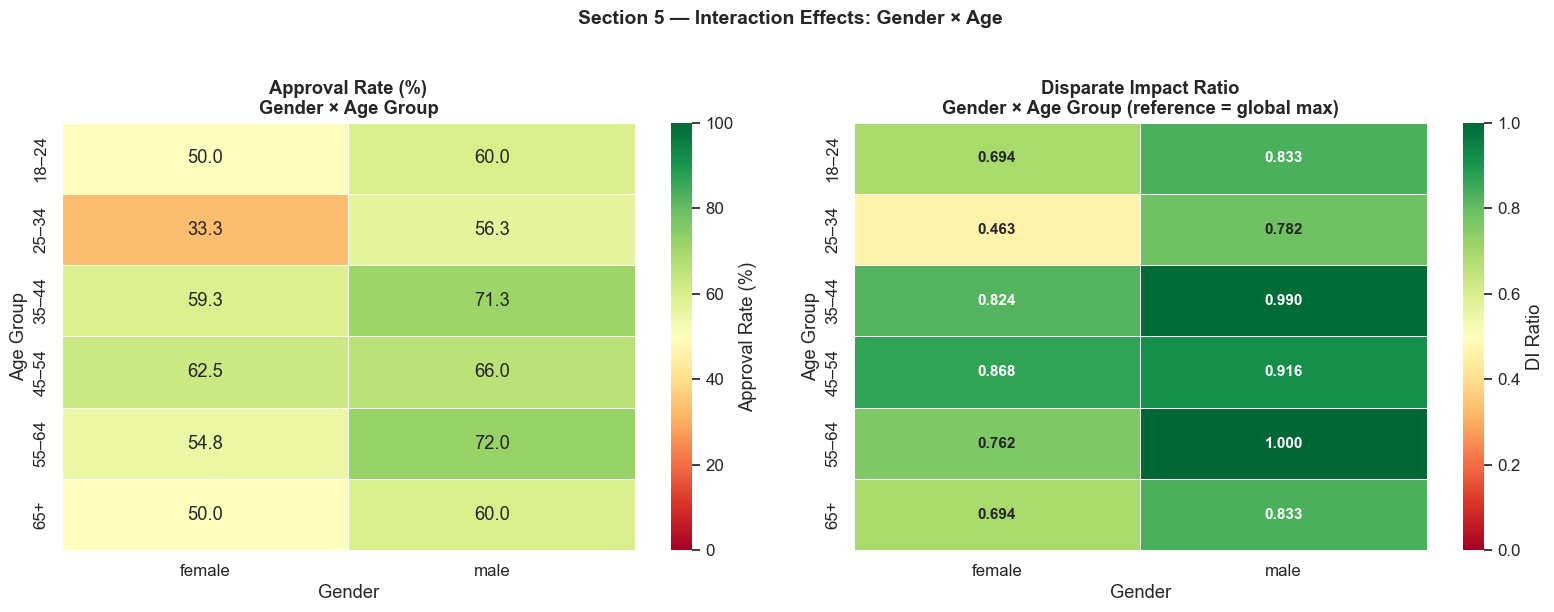

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: heatmap approval rate ----
ax1 = axes[0]
pivot_rate = interaction_stats.pivot(index='age_group', columns='gender', values='approval_rate_pct')
sns.heatmap(pivot_rate, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5,
            ax=ax1, cbar_kws={'label': 'Approval Rate (%)'}, vmin=0, vmax=100)
ax1.set_title('Approval Rate (%)\nGender × Age Group', fontweight='bold')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Age Group')

# ---- Right: DI ratio heatmap ----
ax2 = axes[1]
pivot_di = interaction_stats.pivot(index='age_group', columns='gender', values='DI_ratio')
sns.heatmap(pivot_di, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5,
            ax=ax2, cbar_kws={'label': 'DI Ratio'}, vmin=0, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})
ax2.set_title('Disparate Impact Ratio\nGender × Age Group (reference = global max)', fontweight='bold')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Age Group')

plt.suptitle('Section 5 — Interaction Effects: Gender × Age', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/bias_interaction_effects.png', dpi=150, bbox_inches='tight')
plt.show()

The approval rate heatmap makes the female 25–34 cell immediately visible as the only orange cell in the grid. It is a clear outlier against an otherwise green background.

The DI ratio heatmap shows that the entire female column is lighter than the male column across every age group. There is no age group where female and male approval rates are comparable.
- The 55–64 female cell (DI = 0.761) stands out as a second area of concern — despite being a middle-aged group that passes the single-axis age DI check, the intersectional view reveals it falls below 0.8.
- Male 35–44 and male 55–64 are the two darkest cells (DI = 1.000 and 0.999), being the most favoured subgroups (male and middle-aged).

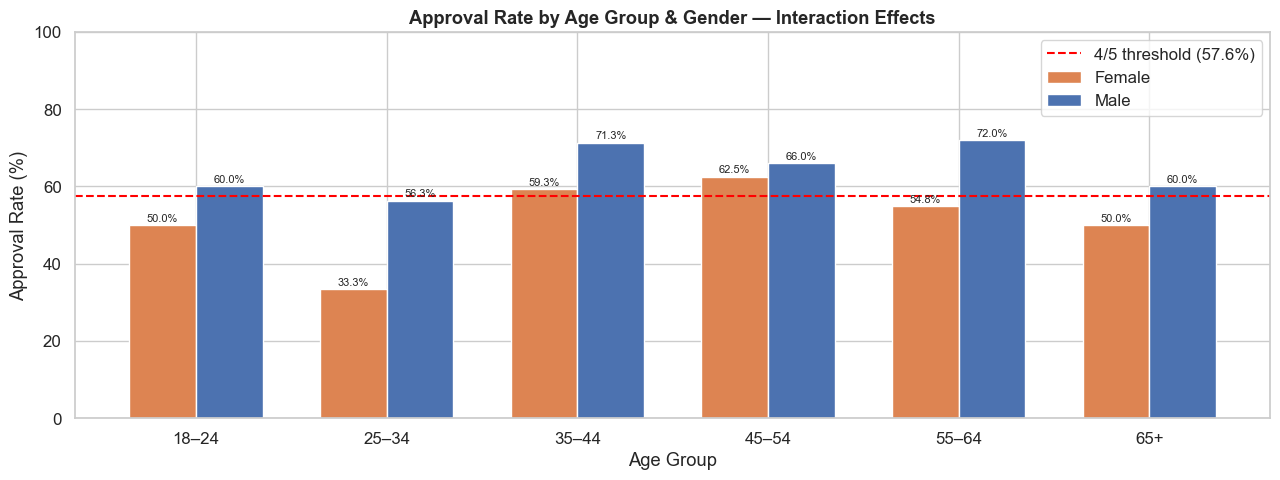

In [17]:
# ── Grouped bar chart: approval rate by age group, split by gender ────────────
fig, ax = plt.subplots(figsize=(13, 5))
colours = {'male': COLOUR_MALE, 'female': COLOUR_FEMALE}

pivot_rate = interaction_stats.pivot(index='age_group', columns='gender', values='approval_rate_pct')
x = np.arange(len(pivot_rate))
width = 0.35

for i, gender in enumerate(pivot_rate.columns):
    bars = ax.bar(x + (i - 0.5) * width, pivot_rate[gender], width,
                  label=gender.capitalize(), color=colours[gender], edgecolor='white')
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(global_max_rate * THRESHOLD * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'4/5 threshold ({global_max_rate * THRESHOLD * 100:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(pivot_rate.index)
ax.set_xlabel('Age Group')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Approval Rate by Age Group & Gender — Interaction Effects', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/bias_interaction_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

The 4/5 threshold line sits at 57.6%.
In every age group, the male bar either meets (25-34 almost) or exceeds the threshold while the female bar frequently does not. This pattern across all six groups reinforces that the gender gap is not isolated to one cohort.

In [18]:
# ── Highlight intersectional subgroups below DI threshold ────────────────────
below_threshold = interaction_stats[interaction_stats['DI_ratio'] < THRESHOLD].copy()
print(f'Subgroups with DI < {THRESHOLD} (intersectional disparate impact):')
if len(below_threshold) == 0:
    print('  None — all gender × age subgroups pass the Four-Fifths Rule. ✅')
else:
    print(f'  {len(below_threshold)} subgroup(s) flagged:')
    display(below_threshold[['age_group','gender','approval_rate_pct','DI_ratio']].set_index(['age_group','gender']))
    print()
    print('⚠️  Intersectional discrimination: these groups face compounded disadvantage.')
    print('   A bias fix addressing gender alone or age alone would miss these subgroups.')

Subgroups with DI < 0.8 (intersectional disparate impact):
  5 subgroup(s) flagged:


approval_rate_pct  DI_ratio
age_group gender                             
18–24     female              50.00    0.6944
25–34     female              33.33    0.4630
          male                56.34    0.7825
55–64     female              54.84    0.7616
65+       female              50.00    0.6944


⚠️  Intersectional discrimination: these groups face compounded disadvantage.
   A bias fix addressing gender alone or age alone would miss these subgroups.


5 subgroups fail the Four-Fifths Rule at the intersectional level:

- 25–34 female (DI = 0.463) — the most severe violation in the entire analysis
- 25–34 male (DI = 0.782) — notably, even male applicants in this age group fall below threshold, suggesting the 25–34 disadvantage has both an age component and a gender-amplified component
- 18–24 female (DI = 0.694), 55–64 female (DI = 0.761), 65+ female (DI = 0.694)

4 of the 5 flagged subgroups are female — confirming that the intersectional disadvantage is primarily driven by the combination of being female and being outside the 35–54 core age range.

In [19]:
# ── Statistical test — Gender effect within each Age Group ───────────────────
# Tests whether gender discrimination is consistent or varies across age groups.
# A significant result in specific groups confirms intersectional bias.

print('Chi-square test per age group — Gender vs Approval')
print('(Significant p means gender discrimination is real within that age group)')
print('-' * 65)

interaction_tests = []
for age_grp in df_interact['age_group'].cat.categories:
    subset = df_interact[df_interact['age_group'] == age_grp]
    if len(subset) < 20:
        continue
    ct = pd.crosstab(subset['gender'], subset[OUTCOME_COL])
    if ct.shape == (2, 2):
        chi2_i, p_i, _, _ = chi2_contingency(ct)
        n_i   = len(subset)
        v_i   = np.sqrt(chi2_i / n_i)
        interaction_tests.append({
            'age_group':   str(age_grp),
            'n':           n_i,
            'chi2':        round(chi2_i, 4),
            'p_value':     round(p_i,    4),
            'cramers_v':   round(v_i,    4),
            'significant': '⚠️  Yes' if p_i < 0.05 else '✅  No'
        })

interact_test_df = pd.DataFrame(interaction_tests).set_index('age_group')
display(interact_test_df)

print()
sig_groups = interact_test_df[interact_test_df['significant'] == '⚠️  Yes']
if len(sig_groups) > 0:
    print(f'⚠️  Gender discrimination is statistically significant in {len(sig_groups)} age group(s):')
    print(f'   {sig_groups.index.tolist()}')
    print('   This confirms intersectional bias — gender and age interact.')
else:
    print('✅ Gender effect is not statistically significant within any individual age group.')
    print('   Any overall gender gap may be driven by age group composition differences.')

Chi-square test per age group — Gender vs Approval
(Significant p means gender discrimination is real within that age group)
-----------------------------------------------------------------


,n,chi2,p_value,cramers_v,significant
age_group,,,,,
25–34,149,7.0666,0.0079,0.2178,⚠️ Yes
35–44,180,2.3462,0.1256,0.1142,✅ No
45–54,87,0.0123,0.9116,0.0119,✅ No
55–64,56,1.0839,0.2978,0.1391,✅ No



⚠️  Gender discrimination is statistically significant in 1 age group(s):
   ['25–34']
   This confirms intersectional bias — gender and age interact.


Gender discrimination is statistically significant in exactly one age group: 25–34 (p = 0.0079, Cramér's V = 0.218).
In all other age groups the gender gap is not statistically significant, meaning the overall gender DI violation found in Section 2 is largely driven by the 25–34 cohort specifically.

The 18–24 and 65+ age groups were excluded from the test due to insufficient sample size (n < 20 per cell).Their DI violations therefore remain statistically unconfirmed.

### Key takeaways — Interaction Effects Between Attributes

- The combination of female + 25–34 produces the most severe DI violation in the entire dataset (DI = 0.463): an approval rate 54% lower than the reference group on a relative basis. This pattern is statistically confirmed (p = 0.008) and would be completely invisible in a single-axis analysis
- Gender discrimination is not uniform across age groups. It is concentrated in the 25–34 cohort, where the gender gap is both the largest in absolute terms (23 pp) and the only one that reaches statistical significance
    
    Even male 25–34 applicants fail the threshold (DI = 0.782), suggesting the 25–34 disadvantage has an independent age component on top of the gender amplification — consistent with the credit_history_months proxy identified in Section 4


---

## Lookout Privacy & Governance

The bias findings in this notebook, have direct implications for the privacy and governance analysis that follows. The table below maps each finding to a specific question Notebook 03 should address:

| Source | Finding | Privacy / Governance Implication for Notebook 03 |
|---|---|---|
| Bias NB | `gender` used in DI analysis | `gender` is personal data under GDPR. Its storage and use in model training must be justified under a lawful basis. If disparate impact is confirmed, continued use must be reviewed and documented. |
| Bias NB | `date_of_birth` used to derive age | `date_of_birth` is PII. If age-based DI is detected, the organisation must assess whether storing the full date of birth is proportionate to the analytical need — a data minimisation question under GDPR Art. 5(1)(c). |
| Bias NB | Proxy variables identified (esp. `spending_amount`, `credit_history_months`) | Features that act as demographic proxies must be listed in model governance documentation. Retention of high-risk proxies must be justified against the data minimisation principle. |
| Bias NB | Intersectional subgroups affected | Automated credit decisions affecting specific intersectional groups trigger heightened GDPR Art. 22 obligations and human oversight requirements under the EU AI Act. |
| Data Quality NB | **Duplicate SSNs linked to multiple names** | A Social Security Number appearing under more than one full name is a serious data integrity and privacy issue. Notebook 03 should assess: (1) whether this indicates identity fraud, data entry error, or a data linkage failure; (2) whether the SSN field is stored with appropriate protection; and (3) whether individuals whose records were merged without consent have a right to rectification under GDPR Art. 16. |
| Data Quality NB | `spending_category` derived from raw behavioural data | Collecting and storing spending behaviour goes beyond basic applicant information. Notebook 03 should evaluate whether this constitutes sensitive behavioural data collection, whether it is covered by the stated processing purpose, and whether applicants were informed of its collection. |
| Data Quality NB | `annual_salary` merged into `annual_income` | Data from two sources was combined without a documented reconciliation rule. Notebook 03 should verify that the data provenance is recorded and that combining sources does not violate the purpose limitation principle (GDPR Art. 5(1)(b)). |
| Both NBs | No `consent_timestamp` in dataset | Individuals whose data is used for automated credit scoring must have consented or another lawful basis must exist. Notebook 03 should verify consent mechanisms and assess whether the absence of this field constitutes a governance gap. |
| Both NBs | No audit trail field | The EU AI Act (Art. 12) requires high-risk AI systems to maintain logs sufficient for post-hoc auditing. A bias finding cannot be investigated or remediated without a decision audit trail. |

### Open Questions for Notebook 03

1. Are `gender`, `date_of_birth`, and `ssn` stored with appropriate technical safeguards (encryption, pseudonymisation)? The duplicate SSN finding makes this especially urgent.
2. Is there a documented lawful basis for processing protected attributes (`gender`, `date_of_birth`) in the context of automated credit scoring?
3. Is the collection of `spending_behavior` data proportionate to the credit-scoring purpose, and were applicants informed of it?
4. Does the organisation have a mechanism to respond to individual subject access or rectification requests — particularly for the individuals affected by the duplicate SSN issue?
5. Is there a human review process for cases in intersectional subgroups flagged as high-risk in Section 5?

> **Regulatory note:** Under the **EU AI Act**, credit scoring systems are classified as high-risk AI (Annex III). This means the organisation must implement risk management, data governance, technical documentation, transparency measures, and human oversight *before* deployment. The data quality issues found in Notebook 01 and the bias patterns found in this notebook are both inputs to that compliance framework — not separate concerns.